# 02 — SQL Funnel Analysis

**Objective:** Use SQL queries to build an engagement funnel and compare control vs treatment groups at each stage.

**Input:** `../data/app_ab_test.db`  
**Output:** `../outputs/figures/02_funnel_*.png`, `../outputs/tables/02_funnel_*.csv`

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Connect to SQLite database
conn = sqlite3.connect('../data/app_ab_test.db')
print('Connected to database ✓')

Connected to database ✓


---
## 1. Overall Funnel — All Users Combined

In [2]:
# Run overall funnel SQL query
# 运行整体漏斗 SQL 查询
funnel_sql = """
SELECT funnel_step, step_order, users, pct_of_total FROM (
    SELECT 'installed'      AS funnel_step, 1 AS step_order,
           COUNT(*) AS users,
           ROUND(COUNT(*)*100.0/(SELECT COUNT(*) FROM users),1) AS pct_of_total
    FROM users
    UNION ALL
    SELECT 'played', 2,
           COUNT(*), ROUND(COUNT(*)*100.0/(SELECT COUNT(*) FROM users),1)
    FROM users WHERE sum_gamerounds > 0
    UNION ALL
    SELECT 'engaged', 3,
           COUNT(*), ROUND(COUNT(*)*100.0/(SELECT COUNT(*) FROM users),1)
    FROM users WHERE sum_gamerounds >= 5
    UNION ALL
    SELECT 'highly_engaged', 4,
           COUNT(*), ROUND(COUNT(*)*100.0/(SELECT COUNT(*) FROM users),1)
    FROM users WHERE sum_gamerounds >= 30
    UNION ALL
    SELECT 'retained_day1', 5,
           COUNT(*), ROUND(COUNT(*)*100.0/(SELECT COUNT(*) FROM users),1)
    FROM users WHERE retention_1 = 1
    UNION ALL
    SELECT 'retained_day7', 6,
           COUNT(*), ROUND(COUNT(*)*100.0/(SELECT COUNT(*) FROM users),1)
    FROM users WHERE retention_7 = 1
) ORDER BY step_order
"""

df_funnel = pd.read_sql_query(funnel_sql, conn)
print('=== Overall Funnel ===')
print(df_funnel[['funnel_step', 'users', 'pct_of_total']].to_string(index=False))

=== Overall Funnel ===
   funnel_step  users  pct_of_total
     installed  90189         100.0
        played  86195          95.6
       engaged  68464          75.9
highly_engaged  33269          36.9
 retained_day1  40153          44.5
 retained_day7  16781          18.6


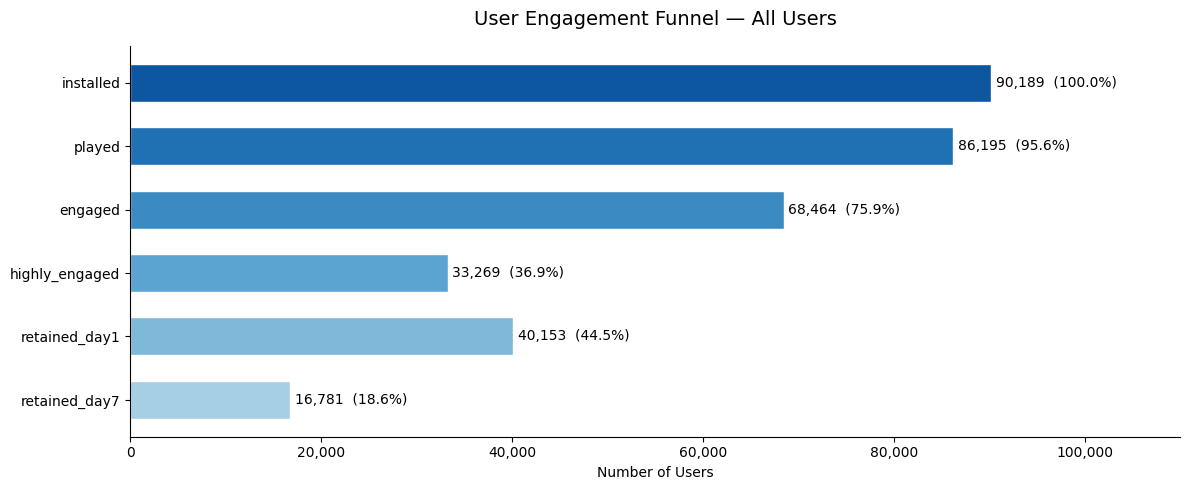

Figure saved ✓


In [3]:
# Plot overall funnel
# 画整体漏斗图
labels = df_funnel['funnel_step'].tolist()
values = df_funnel['users'].tolist()
pcts   = df_funnel['pct_of_total'].tolist()

fig, ax = plt.subplots(figsize=(12, 5))

colors = plt.cm.Blues(np.linspace(0.85, 0.35, len(labels)))
bars = ax.barh(labels[::-1], values[::-1], color=colors[::-1], edgecolor='white', height=0.6)

# Add value labels on each bar
for bar, val, pct in zip(bars, values[::-1], pcts[::-1]):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'{val:,}  ({pct}%)', va='center', fontsize=10)

ax.set_title('User Engagement Funnel — All Users', fontsize=14, pad=15)
ax.set_xlabel('Number of Users')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xlim(0, 110000)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/figures/02_funnel_overall.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved ✓')

---
## 2. Funnel by Group — Control vs Treatment

In [4]:
# Run group-level funnel SQL query
# 运行按实验组拆分的漏斗查询
group_sql = """
SELECT
    version,
    COUNT(*) AS installed,
    ROUND(SUM(CASE WHEN sum_gamerounds > 0  THEN 1.0 ELSE 0 END)*100/COUNT(*),1) AS played_rate,
    ROUND(SUM(CASE WHEN sum_gamerounds >= 5  THEN 1.0 ELSE 0 END)*100/COUNT(*),1) AS engaged_rate,
    ROUND(SUM(CASE WHEN sum_gamerounds >= 30 THEN 1.0 ELSE 0 END)*100/COUNT(*),1) AS highly_engaged_rate,
    ROUND(SUM(retention_1)*100.0/COUNT(*),1) AS d1_retention_rate,
    ROUND(SUM(retention_7)*100.0/COUNT(*),1) AS d7_retention_rate
FROM users
GROUP BY version
ORDER BY version
"""

df_group = pd.read_sql_query(group_sql, conn)
print('=== Funnel by Group ===')
print(df_group.to_string(index=False))

=== Funnel by Group ===
version  installed  played_rate  engaged_rate  highly_engaged_rate  d1_retention_rate  d7_retention_rate
gate_30      44700         95.7          76.3                 37.3               44.8               19.0
gate_40      45489         95.5          75.6                 36.5               44.2               18.2


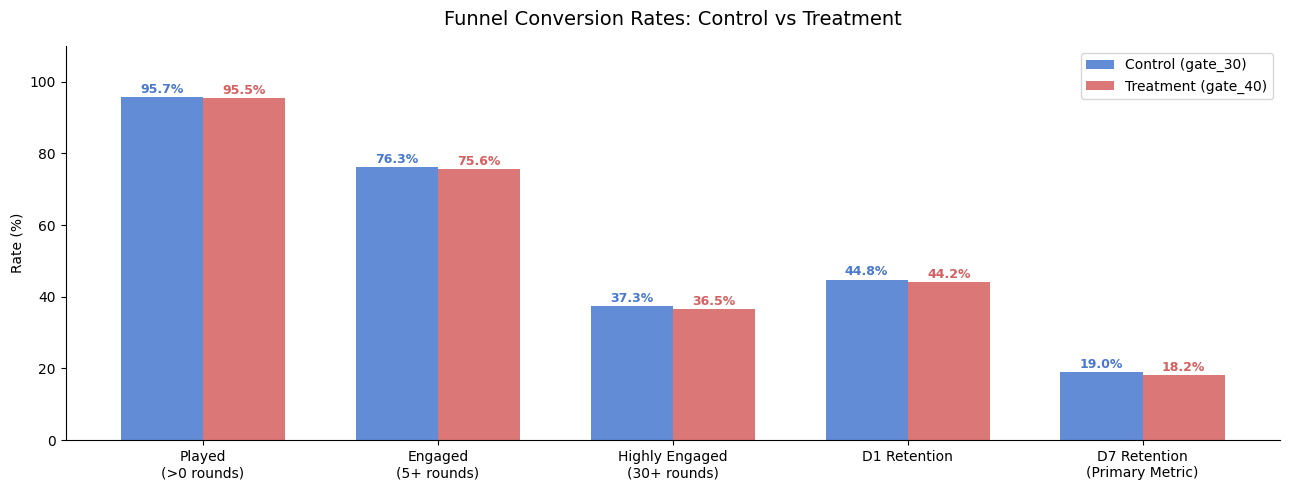

Figure saved ✓


In [5]:
# Plot control vs treatment comparison at each funnel stage
# 画两组在各漏斗阶段的对比图
stages      = ['played_rate', 'engaged_rate', 'highly_engaged_rate', 'd1_retention_rate', 'd7_retention_rate']
stage_labels = ['Played\n(>0 rounds)', 'Engaged\n(5+ rounds)', 'Highly Engaged\n(30+ rounds)', 'D1 Retention', 'D7 Retention\n(Primary Metric)']

ctrl = df_group[df_group['version'] == 'gate_30'][stages].values[0]
trt  = df_group[df_group['version'] == 'gate_40'][stages].values[0]

x = np.arange(len(stages))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
bars1 = ax.bar(x - width/2, ctrl, width, label='Control (gate_30)', color='#4878CF', alpha=0.85)
bars2 = ax.bar(x + width/2, trt,  width, label='Treatment (gate_40)', color='#D65F5F', alpha=0.85)

# Add value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9, color='#4878CF', fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9, color='#D65F5F', fontweight='bold')

ax.set_title('Funnel Conversion Rates: Control vs Treatment', fontsize=14, pad=15)
ax.set_ylabel('Rate (%)')
ax.set_xticks(x)
ax.set_xticklabels(stage_labels, fontsize=10)
ax.legend(fontsize=10)
ax.set_ylim(0, 110)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/figures/02_funnel_by_group.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved ✓')

---
## 3. Key Observations

In [6]:
# Calculate differences between groups at each stage
# 计算两组在每个阶段的差值
diff_data = {
    'Stage': stage_labels,
    'Control (gate_30) %': ctrl,
    'Treatment (gate_40) %': trt,
    'Difference (pp)': (trt - ctrl).round(1)
}
df_diff = pd.DataFrame(diff_data)
df_diff['Direction'] = df_diff['Difference (pp)'].apply(
    lambda x: '▲ Treatment higher' if x > 0 else '▼ Control higher'
)

print('=== Control vs Treatment Differences ===')
print(df_diff.to_string(index=False))

# Save table
df_diff.to_csv('../outputs/tables/02_funnel_comparison.csv', index=False)
df_group.to_csv('../outputs/tables/02_funnel_by_group.csv', index=False)
print('\nTables saved ✓')

=== Control vs Treatment Differences ===
                         Stage  Control (gate_30) %  Treatment (gate_40) %  Difference (pp)        Direction
           Played\n(>0 rounds)                 95.7                   95.5             -0.2 ▼ Control higher
          Engaged\n(5+ rounds)                 76.3                   75.6             -0.7 ▼ Control higher
  Highly Engaged\n(30+ rounds)                 37.3                   36.5             -0.8 ▼ Control higher
                  D1 Retention                 44.8                   44.2             -0.6 ▼ Control higher
D7 Retention\n(Primary Metric)                 19.0                   18.2             -0.8 ▼ Control higher

Tables saved ✓


---
## Summary

| Funnel Stage | Control (gate_30) | Treatment (gate_40) | Difference |
|---|---|---|---|
| Played | 95.7% | 95.5% | -0.2 pp |
| Engaged (5+ rounds) | 76.3% | 75.6% | -0.7 pp |
| Highly Engaged (30+ rounds) | 37.3% | 36.5% | -0.8 pp |
| D1 Retention | 44.8% | 44.2% | -0.6 pp |
| **D7 Retention** | **19.0%** | **18.2%** | **-0.8 pp** |

**Initial observation:** The treatment group (gate_40) shows slightly lower rates at every funnel stage. The primary metric, D7 retention, is 0.8 percentage points lower in the treatment group.

**However**, this is a descriptive comparison only. We cannot conclude whether this difference is statistically significant without hypothesis testing.

**Next:** `03_ab_test_retention_analysis.ipynb` — hypothesis testing and confidence intervals.

In [7]:
conn.close()
print('Database connection closed ✓')

Database connection closed ✓
